# Tutorial: Querying and Managing Data

This notebook walks through loading `.h5` trial files, exploring the xarray Dataset
structure, running queries, detecting and extracting saccades, and saving derived data.

**Requirements**: run from the `magno_tracker/notebooks/` directory (or adjust `H5_DIR` below).

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Resolve the magno_tracker package from the notebooks folder
REPO_ROOT = Path('..').resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from magno_tracker.tracking import TrackingTrial, TrackingExperiment

H5_DIR = REPO_ROOT / 'h5_files'
print('h5 files found:', len(list(H5_DIR.glob('*.h5'))))

h5 files found: 887


## 1  Loading a single trial

`TrackingTrial(filename)` reads an `.h5` file, converts it to a Zarr store on
first use, then opens the store lazily.  Subsequent loads skip the conversion.

In [2]:
# use regex to find the first file matching the pattern
h5_path = list(H5_DIR.glob('*_pcf_*.h5'))[0]
trial = TrackingTrial(filename=h5_path)

print('Load success:', trial.load_success)
print('num_tests:', trial.num_tests)
print('num_frames:', trial.num_frames)
print('framerate:', trial.framerate)

Load success: True
num_tests: 1
num_frames: 1500
framerate: 60.0


### 1.1  Exploring the xarray Dataset

`trial.h5_file` is a lazily-opened `xr.Dataset`.  All variables are listed
under `data_vars`; global metadata lives in `attrs`.

In [3]:
ds = trial.h5_file
print('Variables:', list(ds.data_vars))
print('Dimensions:', dict(ds.dims))
print('Attributes:', dict(ds.attrs))

Variables: ['body_angle', 'body_angle_corrected', 'camera_heading', 'dlc_body_angle', 'dlc_body_angle_corrected', 'dlc_head_angle', 'gaze', 'head_angle', 'is_test', 'odor displacement', 'odor error', 'saccade_amplitude', 'saccade_duration', 'saccade_frequency', 'saccade_isi', 'saccade_peak_velocity', 'saccading_left', 'saccading_right']
Dimensions: {'test': 1, 'frame': 1500}
Attributes: {'cond_label': 'FH', 'condition': 'Fed and Hydrated', 'duration': 25, 'fly_id': 'fh_pcf_10_new', 'genotype': 'Drosophila melanogaster (WT)', 'modified_time': 1689027850.0, 'odor': 'water', 'original_folder': 'NewControl\\PCF_FH\\vid_Angles', 'phase': 'new', 'repetition': 1, 'species_label': 'D. mel', 'texture': 'stripes'}


C:\Users\johnp\AppData\Local\Temp\ipykernel_26708\156850328.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Dimensions:', dict(ds.dims))


In [4]:
# Preview one variable — data is loaded lazily on access
ds['camera_heading']

<xarray.DataArray 'camera_heading' (test: 1, frame: 1500)> Size: 12kB
array([[-1.149354, -1.148134, -1.141241, ...,  2.754107,  2.401975,  2.109343]],
      shape=(1, 1500))
Dimensions without coordinates: test, frame

## 2  Basic queries

`trial.query(output)` returns a NumPy array of shape `(n_tests, n_frames)`
for 2-D variables, or `(n_tests,)` for 1-D ones.

In [5]:
# Full heading time-series for all tests
heading = trial.query('camera_heading')
print('Shape:', heading.shape)   # (n_tests, n_frames)

Shape: (1, 1500)


In [6]:
# Subset by a scalar condition
heading_c1 = trial.query('camera_heading', subset={'condition': 'Fed and Hydrated'})
print('Fed and Hydrated tests:', heading_c1.shape[0])

Fed and Hydrated tests: 1


In [7]:
# Membership filter — keep only data from conditions 1 and 3
heading_c13 = trial.query('camera_heading', subset={'condition': ['Fed and Hydrated', 'Starved and Dehydrated']})
print('Conditions 1 and 3 tests:', heading_c13.shape[0])

Conditions 1 and 3 tests: 0


In [8]:
# Inequality string filter on trial-level attributes
heading_pos_gain = trial.query('camera_heading', subset={'duration': '>20'})
print('Duration >20 tests:', heading_pos_gain.shape[0])

Duration >20 tests: 1


In [9]:
# Inequality string filter on test-level variables
headings = trial.query('camera_heading', subset={'time': '<10'})
print('Shape:', headings.shape)   # (n_tests, n_frames-10)

Shape: (1, 1500)


### 2.1  Quick plot

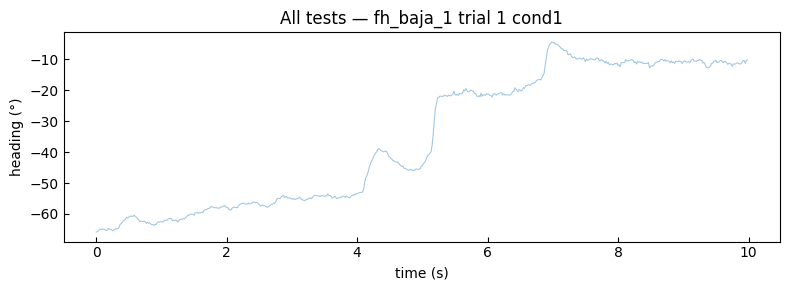

In [10]:
conditions = trial.query('condition')         # shape (n_tests,)
time = np.arange(heading.shape[1]) / trial.framerate

fig, ax = plt.subplots(figsize=(8, 3))
for i, row in enumerate(headings):
    ax.plot(time, np.degrees(row), alpha=0.4, lw=0.8, label=f'cond {conditions[i]}')
ax.set_xlabel('time (s)')
ax.set_ylabel('heading (°)')
ax.set_title('All tests — fh_baja_1 trial 1 cond1')
plt.tight_layout()
plt.show()

## 3  Adding and saving derived datasets

`add_dataset` writes to the in-memory xarray Dataset and marks the variable as
pending.  `save()` flushes only the changed arrays to the `.zarr` store.

Query of new variable OK, shape: (1, 1500)


C:\Users\johnp\AppData\Local\Temp\ipykernel_26708\992502714.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


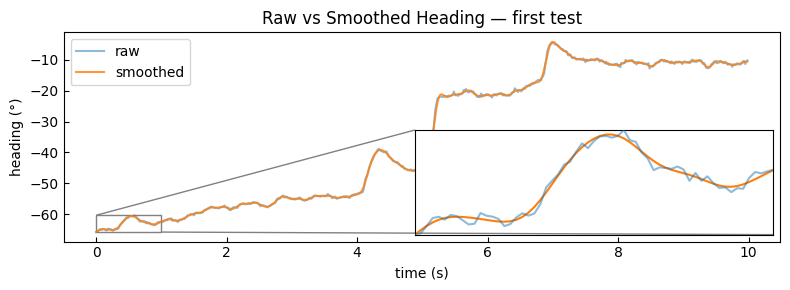

In [17]:
from magno_tracker.tracking import omit_wrapping
from scipy.signal import butter, filtfilt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def smooth(arr, cutoff_hz=20, framerate=60):
    """Butterworth low-pass filter applied row-wise."""
    b, a = butter(4, cutoff_hz / (framerate / 2), btype='low')
    return np.array([filtfilt(b, a, row) for row in arr])

# first, we can unwrap the camera heading to avoid discontinuities at the wrap point
trial.unwrap('camera_heading')

raw = trial.query('camera_heading_unwrapped', subset={'time': '<10'})

# smooth the unwrapped heading using a butterworth bandpass filter
trial.butterworth_filter(key='camera_heading_unwrapped', sample_rate=trial.framerate, low=0, high=5)

# Verify it is immediately queryable
check = trial.query('camera_heading_unwrapped_smoothed', subset={'time': '<10'})
print('Query of new variable OK, shape:', check.shape)

# plot a comparison of raw vs smoothed for the first test
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time, np.degrees(raw[0]), label='raw', alpha=0.5)
ax.plot(time, np.degrees(check[0]), label='smoothed', alpha=0.8)
# add an inset zoming in on 0-1 s to show the smoothing effect more clearly

axins = inset_axes(ax, width="50%", height="50%", loc='lower right')
axins.plot(time, np.degrees(raw[0]), label='raw', alpha=0.5, zorder=3)
axins.plot(time, np.degrees(check[0]), label='smoothed', alpha=1, zorder=2)
axins.set_xlim(0, 1)
axins.set_ylim(np.degrees(raw[0][:int(trial.framerate)]).min(), np.degrees(raw[0][:int(trial.framerate)]).max())
axins.set_xticks([])
axins.set_yticks([])
# draw a box on the main plot to show the zoomed region
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='0.5')

ax.set_xlabel('time (s)')
ax.set_ylabel('heading (°)')
ax.set_title('Raw vs Smoothed Heading — first test')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Save to disk (writes only camera_heading_smooth, not the whole dataset)
trial.save()
print('Saved.')

Saved.


## 4  Experiment-level queries

`TrackingExperiment(dirname)` loads every `.h5` file in a directory.
You can also build one manually from a list of `TrackingTrial` objects.

In [20]:
# Load 3 trials for fly 1 (one per trial number)
files = sorted(H5_DIR.glob('*_pcf_*.h5'))
trials = [TrackingTrial(str(f)) for f in files]
trials = [t for t in trials if t.load_success]

exp = TrackingExperiment.__new__(TrackingExperiment)
exp.trials = trials
print(f'Loaded {len(exp.trials)} trials')

Loaded 432 trials


In [21]:
# Experiment-level query: returns ndarray (n_trials, n_tests, n_frames) when sizes match
all_heading = exp.query(output='camera_heading')
print('Shape:', all_heading.shape)   # (n_trials, n_tests, n_frames)

Shape: (432, 1, 1500)


In [24]:
# Filter across the experiment
heading_c1 = exp.query(output='camera_heading', subset={'condition': 'Fed and Hydrated'}, skip_empty=True)
print('Fed and Hydrated, all trials:', heading_c1.shape)

Fed and Hydrated, all trials: (224, 1, 1500)


## 5  Saccade detection and extraction

In [34]:
# Option to display saccade detection progress
DISPLAY = False

# Detect saccades on all trials
exp.detect_saccades(display=DISPLAY, theshold_speed=50)

# How many per trial?
for t in exp.trials:
    print(f'  {Path(t.filename).name}: {len(t.saccade_table)} saccades')

  fh_pcf_10_new_trial_1_cond1_new.h5: 6 saccades
  fh_pcf_10_new_trial_1_cond2_new.h5: 3 saccades
  fh_pcf_10_new_trial_1_cond3_new.h5: 4 saccades
  fh_pcf_10_new_trial_1_cond4_new.h5: 8 saccades
  fh_pcf_10_new_trial_2_cond1_new.h5: 3 saccades
  fh_pcf_10_new_trial_2_cond2_new.h5: 8 saccades
  fh_pcf_10_new_trial_2_cond3_new.h5: 1 saccades
  fh_pcf_10_new_trial_2_cond4_new.h5: 0 saccades
  fh_pcf_10_new_trial_3_cond1_new.h5: 7 saccades
  fh_pcf_10_new_trial_3_cond2_new.h5: 4 saccades
  fh_pcf_10_new_trial_3_cond3_new.h5: 3 saccades
  fh_pcf_10_new_trial_3_cond4_new.h5: 11 saccades
  fh_pcf_10_old_trial_1_cond1_old.h5: 35 saccades
  fh_pcf_10_old_trial_1_cond2_old.h5: 16 saccades
  fh_pcf_10_old_trial_1_cond3_old.h5: 6 saccades
  fh_pcf_10_old_trial_1_cond4_old.h5: 5 saccades
  fh_pcf_10_old_trial_2_cond1_old.h5: 16 saccades
  fh_pcf_10_old_trial_2_cond2_old.h5: 8 saccades
  fh_pcf_10_old_trial_2_cond3_old.h5: 3 saccades
  fh_pcf_10_old_trial_2_cond4_old.h5: 12 saccades
  fh_pcf_10_old

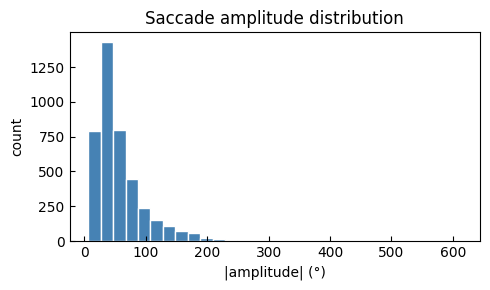

In [35]:
# Flat list of amplitudes across the experiment (one value per saccade)
amps = exp.query(object='saccade', output='amplitude')
amps_deg = np.degrees(np.abs(amps))

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(amps_deg, bins=30, color='steelblue', edgecolor='w')
ax.set_xlabel('|amplitude| (°)')
ax.set_ylabel('count')
ax.set_title('Saccade amplitude distribution')
plt.tight_layout()
plt.show()

In [36]:
# Mean amplitude per test (groupby='test')
mean_amps = exp.query(object='saccade', output='amplitude', groupby='test')
print('Type:', type(mean_amps))
print('Length (one entry per trial):', len(mean_amps))
print('Example first-trial per-test means:', np.degrees(mean_amps[0]))

Type: <class 'list'>
Length (one entry per trial): 408
Example first-trial per-test means: -60.98229220711405


In [37]:
# Filter by peak velocity > 5 rad/s
fast_amps = exp.query(object='saccade', output='amplitude',
                      subset={'peak_velocity': '>5'})
print('Fast saccades:', len(fast_amps), 'out of', len(amps))

Fast saccades: 2047 out of 4152


### 5.1  Saccade table as a pandas DataFrame

In [30]:
df = exp.saccade_table_df(extra_cols=['condition', 'fly_id'])
df.head(10)

,trial_filename,test_ind,test_start_frame,start_frame,stop_frame,peak_frame,amplitude,peak_velocity,duration,start_angle,stop_angle,condition,fly_id
0,fh_pcf_10_new_trial_1_cond1_new.h5,0,0,885,904,891,-1.359978,-17.199256,0.316667,-0.438351,-1.798330,Fed and Hydrated,fh_pcf_10_new
1,fh_pcf_10_new_trial_1_cond1_new.h5,0,0,944,953,947,-0.550926,-7.209728,0.150000,-2.310508,-2.861435,Fed and Hydrated,fh_pcf_10_new
2,fh_pcf_10_new_trial_1_cond1_new.h5,0,0,970,986,976,-1.932573,-20.598487,0.266667,-2.910888,-4.843461,Fed and Hydrated,fh_pcf_10_new
3,fh_pcf_10_new_trial_1_cond1_new.h5,0,0,992,996,994,-0.424591,-7.186845,0.066667,-4.854369,-5.278960,Fed and Hydrated,fh_pcf_10_new
4,fh_pcf_10_new_trial_1_cond1_new.h5,0,0,1224,1234,1228,-0.638099,-6.906248,0.166667,-7.007674,-7.645773,Fed and Hydrated,fh_pcf_10_new
5,fh_pcf_10_new_trial_1_cond1_new.h5,0,0,1492,1499,1497,-1.479883,-21.350807,0.116667,-8.977145,-10.457028,Fed and Hydrated,fh_pcf_10_new
6,fh_pcf_10_new_trial_1_cond2_new.h5,0,0,538,551,545,1.063171,14.780999,0.216667,-1.190611,-0.127441,Fed and Hydrated,fh_pcf_10_new
7,fh_pcf_10_new_trial_1_cond2_new.h5,0,0,701,708,705,-0.313663,-6.434982,0.116667,-0.580586,-0.894249,Fed and Hydrated,fh_pcf_10_new
8,fh_pcf_10_new_trial_1_cond2_new.h5,0,0,983,998,987,0.667564,6.587107,0.250000,-0.664469,0.003096,Fed and Hydrated,fh_pcf_10_new
9,fh_pcf_10_new_trial_1_cond3_new.h5,0,0,965,976,970,0.805018,9.150388,0.183333,-0.256602,0.548416,Fed and Hydrated,fh_pcf_10_new


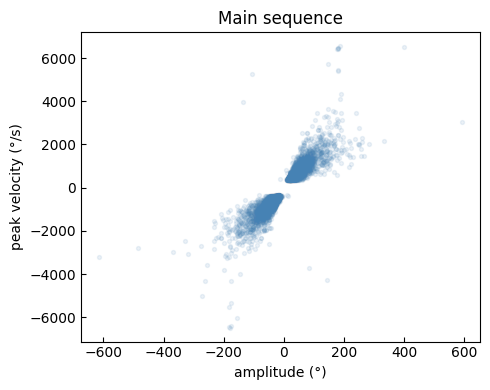

In [39]:
df['amplitude_deg'] = np.degrees(df['amplitude'])
df['peak_velocity_deg_s'] = np.degrees(df['peak_velocity'])

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(df['amplitude_deg'], df['peak_velocity_deg_s'],
           s=8, alpha=0.1, color='steelblue')
ax.set_xlabel('amplitude (°)')
ax.set_ylabel('peak velocity (°/s)')
ax.set_title('Main sequence')
plt.tight_layout()
plt.show()

### 5.2  On-demand Saccade object reconstruction

In [40]:
# Retrieve reconstructed Saccade objects from the first trial
saccades = exp.trials[0].query(output='saccade', object='saccade')
s = saccades[0]

print('amplitude:', np.degrees(s.amplitude), '°')
print('peak_velocity:', np.degrees(abs(s.peak_velocity)), '°/s')
print('duration:', s.duration, 's')
print('arr_relative shape:', s.arr_relative.shape)
print('velocity shape:', s.velocity.shape)

amplitude: -77.92101449328266 °
peak_velocity: 985.4447895393816 °/s
duration: 0.31666666666666643 s
arr_relative shape: (1500,)
velocity shape: (1500,)


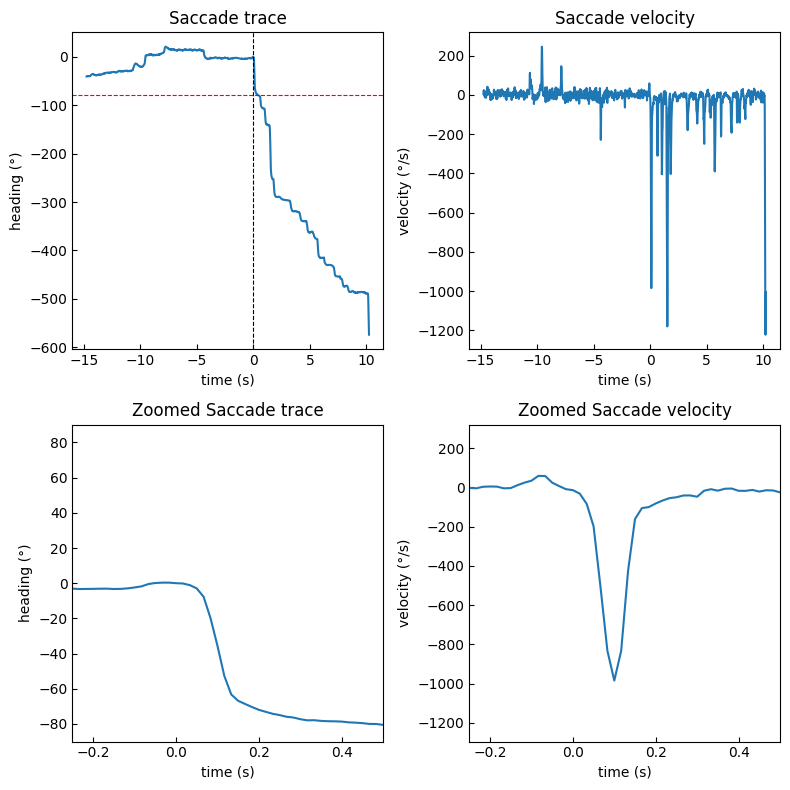

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
row = axes[0]
row[0].plot(s.start_relative_time, np.degrees(s.arr_relative))
row[0].set_xlabel('time (s)')
row[0].set_ylabel('heading (°)')
row[0].set_title('Saccade trace')
# draw a vertical line at time 0 to indicate saccade onset
row[0].axvline(0, color='k', ls='--', lw=0.8)
# and a horizontal line at the amplitude value
row[0].axhline(np.degrees(s.amplitude), color='r', ls='--', lw=0.8)

row[1].plot(s.start_relative_time, np.degrees(s.velocity))
row[1].set_xlabel('time (s)')
row[1].set_ylabel('velocity (°/s)')
row[1].set_title('Saccade velocity')
# second row should be a zoomed inset of -.25 to .5 s of the first row
row = axes[1]
row[0].plot(s.start_relative_time, np.degrees(s.arr_relative))
row[0].set_xlabel('time (s)')
row[0].set_ylabel('heading (°)')
row[0].set_title('Zoomed Saccade trace')
row[0].set_xlim(-0.25, 0.5)
row[0].set_ylim(-90, 90)
row[1].plot(s.start_relative_time, np.degrees(s.velocity))
row[1].set_xlabel('time (s)')
row[1].set_ylabel('velocity (°/s)')
row[1].set_title('Zoomed Saccade velocity')
row[1].set_xlim(-0.25, 0.5)


plt.tight_layout()
plt.show()

## 6  Saving and reloading — round-trip verification

In [47]:
# Save saccade tables for all trials
exp.save()
print('Saved.')

Saved.


In [48]:
# Reload from disk and verify saccades are intact
trial_fresh = TrackingTrial(str(files[0]))
amps_reloaded = trial_fresh.query(output='amplitude', object='saccade')
amps_original = exp.trials[0].query(output='amplitude', object='saccade')

print('Saccade count matches:', len(amps_reloaded) == len(amps_original))
print('Values match:', np.allclose(amps_reloaded, amps_original))

Saccade count matches: True
Values match: True
